# GUV Image Analysis Pipeline

This notebook contains a demo pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It single-frame data from .tif files.
For movie-style analysis, we apply the same tools but in a more automated format, saving more intermediate material. Here, we collect a ll the basic steps.

Jacob Kers, 2024

## Imports and Setup

In [147]:
import csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import numpy as np
from skimage import io
from skimage import measure
#customs:
import guv_binary_ops
import guv_tools

# set up autoreload on all files
%load_ext autoreload
%autoreload 2

plt.rcParams['figure.figsize'] = [7, 5]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Giant Unilamellar Vesicle or GUV
Our basic 'info unit' is a single GUV, we note it as ROI (region-of-interest).  We keep track of where it came from via a simple excel table, easily readable for both user and Python. The 'GUV' class closely follows the header in the Excel table. Here, we index per movie, then per ROI. For a single GUV or ROI, we define a 'GUV object'.


In [148]:
class GUV:
    def __init__(self):
        self.pathname = 0
        self.filename = 0
        self.exp_id = 0
        self.movie_id = 0
        self.guv_id = 0
        self.use_it = 0
        self.notes = 'any note'

# Collect info
read GUV info from an Excel file and returns a list of GUV objects for a specific run ID.
We define a `GUV` class to store properties of a single GUV movie.

In [149]:
# Example usage
if 1: 
    excelpath=str("D:/jkerssemakers/Dropbox/CD_recent/BN_CD24_Bert/")
    excelname =str("Bert_data_overview.xlsx")
wb = load_workbook(excelpath+excelname)
sheet_files = wb['guvs']
# Create a dictionary of column names:
Header = {COL[0].value: idx for idx, COL in enumerate(sheet_files.iter_cols(1, sheet_files.max_column))}
#pick one particular experiment (or more):
exp_id=1

#build a list of 'GUV' objects:
Guv_list = []
for row_cells in sheet_files.iter_rows(min_row=2, max_row=sheet_files.max_row):
    Guv = GUV()
    Guv.pathname = row_cells[Header["pathname"]].value
    Guv.filename = row_cells[Header["filename"]].value
    Guv.exp_id = row_cells[Header["exp_id"]].value
    Guv.movie_id = row_cells[Header["movie_id"]].value
    Guv.label = row_cells[Header["guv_id"]].value
    Guv.use_it = row_cells[Header["use_it"]].value
    Guv.crop_it = row_cells[Header["notes"]].value
    if Guv.exp_id == exp_id:
        Guv_list.append(Guv)
        print(Guv.filename)



1mM_cholDNA_647dna_overnight_1028.tif
1mM_cholDNA_647dna_overnight_1029.tif
1mM_cholDNA_647dna_overnight_1030.tif


## Main Analysis Pipeline
pick a GUV and show its color channels and the 'work image', which is just the sum of these channels:


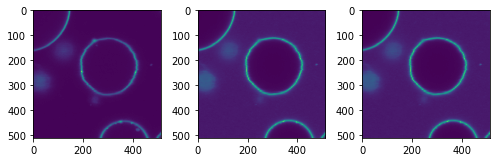

In [150]:
Guv = Guv_list[2]
image_path = Guv.pathname + '\\' + Guv.filename
roi = np.array(io.imread(image_path))
# extract other basic metadata
clrs, rr,cc,=np.shape(roi)
fig, axs = plt.subplots(1, clrs +1)
#setup a work image for edge detection etc
for color_i, chan in enumerate(roi):
    if color_i==0: 
        roi_work=chan-np.min(chan)
    else:
            roi_work=+ chan - np.min(chan)
            roi_main = chan  #to be used later
    axs[color_i].imshow(chan) 
axs[color_i+1].imshow(roi_work)
fig.tight_layout()
plt.show()              

# Isolating a GUV

We perform a series of binary operations to isolate the single GUV-of-interest. Once this is done, we get a first set of measurement parameters from the binarized, filled-up overall shape. These parameters (such as center-of-mass position) can later be used for more refined processing such as radial edge detection

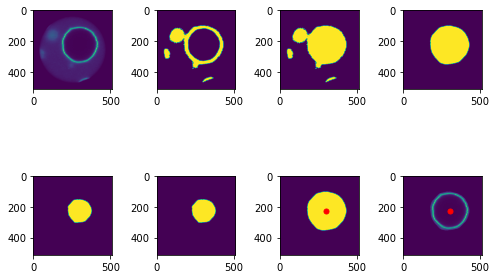

In [151]:
# set the scale of erosion /dilation
disk_sz=int(0.02*np.shape(roi_work)[0])

if np.max(np.array(roi_work))>0:
    roi_work=guv_tools.soft_mask_it(roi_work)
    roi_work=guv_tools.smooth_it(roi_work,labda=2)
    roi_work= roi_work.astype(int)
    
    #transfer to binary operations to gat masks and robust coordinates
    mask_0=guv_binary_ops.sorted_pixels_treshold(roi_work)[1]
    mask_1 = guv_binary_ops.binary_fill_holes(mask_0, guv_binary_ops.disk(disk_sz))
    mask_2 = guv_binary_ops.binary_opening(mask_1, guv_binary_ops.disk(disk_sz), iterations = 6)
    mask_3 = guv_binary_ops.binary_erosion(mask_2, guv_binary_ops.disk(disk_sz), iterations = 5)
    mask_4 = guv_binary_ops.mask_central_object(mask_3)[0]
    mask_5 = guv_binary_ops.binary_dilation(mask_4, guv_binary_ops.disk(disk_sz), iterations = 5)
    
    #get some basic shape properties:
    labels, n_labels = measure.label(mask_5, return_num = True)
    regprops = measure.regionprops(labels)
    xm,ym = regprops[0].centroid
    rmin=regprops[0].axis_minor_length/2
    rmaj=regprops[0].axis_major_length/2
    area=regprops[0].area
    perimeter= regprops[0].perimeter
    
    #show:
    fig, axs = plt.subplots(2, 4)
    axs[0,0].imshow(roi_work)
    axs[0,1].imshow(mask_0)
    axs[0,2].imshow(mask_1)
    axs[0,3].imshow(mask_2)
    axs[1,0].imshow(mask_3)
    axs[1,1].imshow(mask_4)
    axs[1,2].imshow(mask_5)
    axs[1,2].plot(ym,xm, 'ro', markersize=5)
    axs[1,3].imshow(roi_work*mask_5)
    axs[1,3].plot(ym,xm, 'ro', markersize=5)
    fig.tight_layout()
    plt.show()

# extra masks

For convenience, we introduce some extra masks:


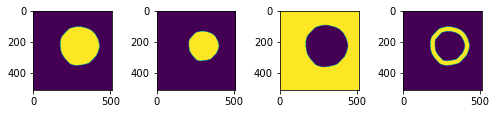

In [152]:
inner_mask = guv_binary_ops.binary_erosion(mask_5, guv_binary_ops.disk(disk_sz), iterations = 3)                 
outer_mask = 1-guv_binary_ops.binary_dilation(mask_5, guv_binary_ops.disk(disk_sz), iterations = 1)
edge_mask=mask_5.astype(float) -inner_mask
#show:
fig, axs = plt.subplots(1, 4)
axs[0].imshow(mask_5)
axs[1].imshow(inner_mask)
axs[2].imshow(outer_mask)
axs[3].imshow(edge_mask)
fig.tight_layout()
plt.show()

# Radial mapping

Now we have the center-of mass, we resample the pattern on a radial mesh

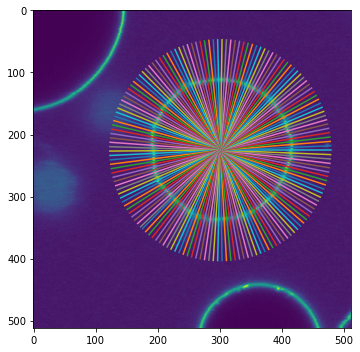

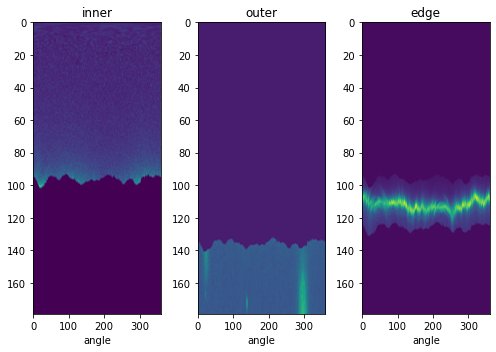

In [153]:
import importlib; importlib.reload(guv_tools)

r_max=int(0.35*np.shape(roi_work)[0])
presets={#
'angularoversampling' : 0.7, 
'radialoversampling' : 2,
'minradius' : 0,#the minimal radius is 0
'maxradius' : r_max
}
edge_map,QI, Xsamplinggrid, Ysamplinggrid=guv_tools.QI_map(edge_mask*roi_main, presets, xm, ym,demo=1)
inner_map=guv_tools.QI_map(inner_mask*roi_main, presets, xm, ym)
outer_map=guv_tools.QI_map(outer_mask*roi_main, presets, xm, ym)
#show:
skips=5
fig, axs = plt.subplots(1, 1)
axs.imshow(roi_main)
axs.plot(Ysamplinggrid[::skips,::skips], Xsamplinggrid[::skips,::skips], '-')
fig.tight_layout()
plt.show()
#show:
#note that we use degrees and pixel units for plotting, not for sampling
rr,aa=edge_map.shape
fig, axs = plt.subplots(1, 3)
axs[0].imshow(inner_map,extent=[0,360,r_max,0], aspect='auto')
axs[0].set_title('inner')
axs[0].set_xlabel('angle')
axs[1].imshow(outer_map,extent=[0,360,r_max,0], aspect='auto')
axs[1].set_title('outer')
axs[1].set_xlabel('angle')
axs[2].imshow(edge_map,extent=[0,360,r_max,0], aspect='auto')
axs[2].set_title('edge')
axs[2].set_xlabel('angle')

fig.tight_layout()
plt.show()

# Edge quantification
We observe a somewhat sinusoid edge intensity variation, due to polarization effects. Here, we choose the maximum amplitude along the edge. We find it by mapping the maximum local intensity (note that we ignore its radial position) and remove the outliers first, then fit a sinusoid.

edge maximum:
203.23316672215773


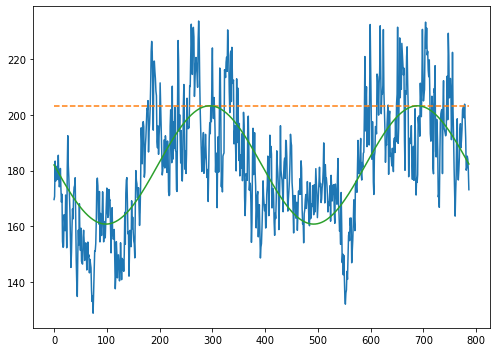

In [154]:

profile=np.nanmax(edge_map, axis=0)

# for a clean fit, we should remove the mean and remove the outliers ('buds')

x=np.arange(len(profile))
inliers, outliers, flags = guv_tools.outlier_flag(profile, tolerance=2.5, sig_change=0.7, how=1, sho=0, demo=0)
cln_x=x[np.nonzero(flags)]
cln_profile=profile[np.nonzero(flags)]

# Fit the sine wave
popt, pcov = guv_tools.fit_sine_to_trace(cln_x, cln_profile)   

# Generate the fitted curve (on original x)
y_fit = guv_tools.sine_function(np.arange(len(x)), *popt)
edge_value=np.max(y_fit)

# this edge value compares to that of an IamgeJ cross-section profile
print('edge maximum:')
print(edge_value)

# show:
fig, axs = plt.subplots(1,1)
axs.plot(cln_x, cln_profile)
axs.plot(cln_x, 0*cln_profile+edge_value, '--')
axs.plot(y_fit)
fig.tight_layout()
plt.show()
dum=1
plt.close("all")

